# Exploratory Data Analysis (EDA)
## Detailed Student Workbook

Exploratory Data Analysis is a structured process for understanding data before cleaning, feature engineering, statistical analysis, or modeling.

The goal is not merely to create charts. A complete EDA should answer:

- Is the dataset valid enough for analysis?
- Which issues require cleaning?
- Which variables appear important?
- Are there clear relationships?
- Are any values impossible or suspicious?
- Is the target balanced?
- Which transformations are required before modeling?

## Topics

1. EDA workflow and analytical questions
2. Loading data
3. Displaying samples
4. Rows, columns, names, and data types
5. Missing values
6. Duplicate rows and duplicate identifiers
7. Descriptive statistics
8. Numerical and categorical distributions
9. Outlier detection
10. Relationships and correlations
11. Class-balance analysis
12. Domain-validity checks
13. Transformations before modeling
14. Findings documentation
15. Final guided EDA project

## Dataset Scenario

A subscription company wants to understand customer churn.

Each row represents one customer.

| Column | Meaning |
|---|---|
| `customer_id` | Unique customer identifier |
| `age` | Customer age |
| `gender` | Customer gender |
| `city` | Customer city |
| `tenure_months` | Number of months with the company |
| `monthly_spend` | Average monthly spending |
| `support_calls` | Number of support calls |
| `satisfaction_score` | Satisfaction score from 1 to 5 |
| `contract_type` | Monthly, quarterly, or annual contract |
| `payment_method` | Customer payment method |
| `is_premium` | Premium membership indicator |
| `purchases_last_6m` | Purchases in the last six months |
| `signup_date` | Signup date |
| `churn` | Target variable: Yes or No |

The dataset intentionally contains missing values, duplicates, unreasonable values, outliers, and class imbalance.

## EDA as a Decision Process

```text
Understand the business question
        ↓
Load and inspect the data
        ↓
Assess quality and validity
        ↓
Analyze each variable
        ↓
Study relationships
        ↓
Inspect the target
        ↓
Identify transformations
        ↓
Document findings and recommendations
```

Each output should support an analytical conclusion.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize
from pandas.core import col

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

print("EDA environment is ready.")

EDA environment is ready.


# 1. Loading Data

## CSV

```python
df = pd.read_csv("file.csv")
```

## Excel

```python
df = pd.read_excel("file.xlsx")
```

## URL

```python
df = pd.read_csv("https://example.com/data.csv")
```

## Google Colab Upload

```python
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)
```

After loading, verify that the DataFrame exists, is not empty, and contains the expected columns.

In [2]:
# Upload the provided file to Google Colab first.
#
# from google.colab import files
# uploaded = files.upload()
# file_name = next(iter(uploaded))
# df = pd.read_csv(file_name)

data_path = Path.cwd() / "content" / "eda_customer_churn_dataset.csv"

# TODO: Load the provided CSV file into a DataFrame named df.
df = pd.read_csv(data_path)

### Exercise 1: Load the Dataset

**Level:** Foundation  
**Learning objective:** Load a CSV file into pandas.

#### Task
Upload the provided CSV file and store it in `df`.

#### Expected result
```text
Expected shape: (328, 14)
```

<details>
<summary><strong>Hint</strong></summary>

Use `pd.read_csv()`.

</details>

In [3]:
# TODO: Load the dataset.
# loaded in the cell above

# TODO: Print df.shape.
print(df.shape)

(328, 14)


### Exercise 2: Safe CSV Loader

**Level:** Applied  
**Learning objective:** Create a reusable data-loading function.

#### Task
Write `load_csv(path)` that checks whether the file exists and rejects an empty DataFrame.

#### Expected result
```text
Return a non-empty DataFrame.
```

<details>
<summary><strong>Hint</strong></summary>

Use `Path.exists()` and `DataFrame.empty`.

</details>

In [4]:
def load_csv(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    df = pd.read_csv(path)
    if df.empty:
        raise ValueError(f"File is empty: {path}")
    return df

# 2. Initial Inspection

Initial inspection answers:

- What does one row represent?
- How many observations and variables exist?
- What columns are available?
- Which variables are numerical or categorical?
- Are the data types appropriate?
- Do random rows look reasonable?

## Useful Methods

| Method | Purpose |
|---|---|
| `head()` | First rows |
| `tail()` | Last rows |
| `sample()` | Random rows |
| `shape` | Rows and columns |
| `columns` | Column names |
| `dtypes` | Data types |
| `info()` | Non-null counts and types |
| `nunique()` | Number of distinct values |

## Data Types

| pandas type | Typical meaning |
|---|---|
| `int64` | Integer |
| `float64` | Decimal number |
| `object` | Text or mixed values |
| `bool` | True/False |
| `datetime64[ns]` | Date/time |
| `category` | Categorical variable |

Dates loaded from CSV usually begin as `object` and should be converted explicitly.

### Exercise 3: Display Samples

**Level:** Foundation  
**Learning objective:** Inspect different areas of the dataset.

#### Task
Display the first five rows, last three rows, and a reproducible sample of five rows.

#### Expected result
```text
Three DataFrame outputs.
```

<details>
<summary><strong>Hint</strong></summary>

Use `head()`, `tail()`, and `sample(random_state=42)`.

</details>

In [5]:
# TODO: Display the three samples.
print("first five rows")
print(df.head(5))

print("\n\nlast three rows")
print(df.tail(3))

print("\n\nsample (reproducible)")
print(df.sample(random_state=42))

first five rows
  customer_id   age  gender     city  tenure_months  monthly_spend  \
0   CUST-0001 39.00    Male   Dammam          28.00         123.92   
1   CUST-0002 25.00    Male   Riyadh           9.00          97.33   
2   CUST-0003 44.00  Female  Madinah          12.00          86.78   
3   CUST-0004 46.00    Male   Riyadh          67.00         104.40   
4   CUST-0005 18.00  Female  Madinah           1.00          97.94   

   support_calls  satisfaction_score contract_type  payment_method  \
0           2.00                3.40       Monthly  Digital Wallet   
1           2.00                3.08        Annual            Cash   
2           1.00                4.13        Annual   Bank Transfer   
3           2.00                3.70       Monthly     Credit Card   
4           6.00                 NaN       Monthly     Credit Card   

   is_premium  purchases_last_6m signup_date churn  
0       False               7.00  2023-09-20    No  
1       False               2.00  20

### Exercise 4: Dataset Dimensions

    **Level:** Foundation  
    **Learning objective:** Interpret `DataFrame.shape`.

    #### Task
    Print rows and columns separately.

    #### Expected result
    ```text
    Rows: 328
Columns: 14
    ```

    <details>
    <summary><strong>Hint</strong></summary>

    Unpack `df.shape`.

    </details>

In [6]:
# TODO: Print rows and columns.
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 328
Columns: 14


### Exercise 5: Column-Type Classification

   **Level:** Applied
   **Learning objective:** Separate numerical and non-numerical variables.

   #### Task
   Create lists named `numeric_columns` and `other_columns`.

   #### Expected result
   ```text
   Numeric columns: 6
   Other columns: 8
   ```

   <details>
   <summary><strong>Hint</strong></summary>

   Use `select_dtypes()`.

   </details>

In [7]:
# TODO: Create both column lists.
numeric_columns = df.select_dtypes(include="number").columns
other_columns = df.select_dtypes(exclude="number").columns

# TODO: Print their names and lengths.
print("Numeric columns:", len(numeric_columns), "->", numeric_columns)
print("Other columns:", len(other_columns), "->", other_columns)

Numeric columns: 6 -> Index(['age', 'tenure_months', 'monthly_spend', 'support_calls',
       'satisfaction_score', 'purchases_last_6m'],
      dtype='str')
Other columns: 8 -> Index(['customer_id', 'gender', 'city', 'contract_type', 'payment_method',
       'is_premium', 'signup_date', 'churn'],
      dtype='str')


### Exercise 6: Convert Signup Date

**Level:** Applied  
**Learning objective:** Convert a text column to datetime.

#### Task
Convert `signup_date` using `errors='coerce'`.

#### Expected result
```text
datetime64[ns]
```

<details>
<summary><strong>Hint</strong></summary>

Use `pd.to_datetime()`.

</details>

In [8]:
# TODO: Convert signup_date.
print("datetime before:", df['signup_date'].dtype)
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')

# TODO: Print the resulting dtype.
print("datetime after:", df['signup_date'].dtype)

datetime before: str
datetime after: datetime64[us]


### Exercise 7: Column Audit Table

**Level:** Challenge  
**Learning objective:** Create a reusable metadata summary.

#### Task
Build a table with column, dtype, non-null count, missing count, unique count, and example value.

#### Expected result
```text
One row per column.
```

<details>
<summary><strong>Hint</strong></summary>

Loop through `df.columns` or combine pandas Series.

</details>

In [9]:
# TODO: Build column_audit.
column_audit = pd.DataFrame(
    [
        {
            "column": col,
            "dtype": df[col].dtype,
            "non_null": df[col].notna().sum(),
            "missing": df[col].isna().sum(),
            "unique": df[col].nunique(),
            "example_value": df[col].dropna().iloc[0],
        }
        for col in df.columns
    ]
)

# TODO: Display it.
print(column_audit.head())

          column    dtype  non_null  missing  unique example_value
0    customer_id      str       328        0     320     CUST-0001
1            age  float64       328        0      47         39.00
2         gender      str       319        9       2          Male
3           city      str       318       10       5        Dammam
4  tenure_months  float64       328        0      72         28.00


# 3. Missing-Value Analysis

Missing values may be represented by:

- `NaN`,
- `None`,
- empty strings,
- placeholders such as `Unknown`, `N/A`, or `-999`.

## Counts

```python
df.isna().sum()
```

## Percentages

```python
df.isna().mean() * 100
```

## Decision Questions

- How much is missing?
- Which variables are affected?
- Is missingness related to a group or target?
- Is the variable important?
- Can it be imputed?
- Would dropping rows introduce bias?

## Possible Treatments

| Situation | Possible action                       |
|---|---------------------------------------|
| Small amount in non-critical rows | Drop affected rows                    |
| Numerical variable | Median or model-based imputation      |
| Categorical variable | Mode or `Unknown`                     |
| Missingness carries information | Add a missing indicator               |
| Very high missingness | Consider dropping the variable        |
| Ordered time data | Forward/backward fill only when justified |

No treatment should be automatic.

### Exercise 8: Missing Counts

**Level:** Foundation  
**Learning objective:** Count missing values.

#### Task
Print missing counts sorted descending.

#### Expected result
```text
Columns with missing values should appear first.
```

<details>
<summary><strong>Hint</strong></summary>

Use `isna().sum().sort_values()`.

</details>

In [10]:
# TODO: Calculate missing counts.
missing_values = df.isna().sum().sort_values(ascending=False)
print(missing_values)

satisfaction_score    12
city                  10
gender                 9
monthly_spend          8
payment_method         5
customer_id            0
tenure_months          0
age                    0
support_calls          0
contract_type          0
is_premium             0
purchases_last_6m      0
signup_date            0
churn                  0
dtype: int64


### Exercise 9: Missing Percentage Summary

**Level:** Applied  
**Learning objective:** Quantify missingness.

#### Task
Create a table with count and percentage, excluding columns with zero missing values.

#### Expected result
```text
One row per affected column.
```

<details>
<summary><strong>Hint</strong></summary>

Filter where missing count is greater than zero.

</details>

In [11]:
# TODO: Build and display missing_summary.
missing_count = df.isna().sum()

missing_summary = pd.DataFrame(
    {
        "missing_count": missing_count,
        "missing_percentage": ((missing_count / len(df)) * 100),
    }
)
# filtering
missing_summary = missing_summary[missing_summary["missing_count"] > 0]

# sorting
missing_summary = missing_summary.sort_values(by="missing_count", ascending=False)

print(missing_summary)

                    missing_count  missing_percentage
satisfaction_score             12                3.66
city                           10                3.05
gender                          9                2.74
monthly_spend                   8                2.44
payment_method                  5                1.52


### Exercise 10: Missingness by Target

**Level:** Challenge  
**Learning objective:** Investigate whether missingness differs across churn classes.

#### Task
Compare the missing rate of satisfaction score between churn classes.

#### Expected result
```text
A grouped missing-rate table.
```

<details>
<summary><strong>Hint</strong></summary>

Create a Boolean indicator then group by `churn`.

</details>

In [12]:
# TODO: Compare missing satisfaction by churn.
missing_by_churn = df["satisfaction_score"].isna().groupby(df["churn"]).mean() * 100
print(missing_by_churn)

churn
No    3.40
Yes   5.88
Name: satisfaction_score, dtype: float64


### Exercise 11: Missing-Value Decision Table

**Level:** Challenge  
**Learning objective:** Turn analysis into recommendations.

#### Task
Document variable, missing percentage, proposed action, and justification for each affected column.

#### Expected result
```text
One recommendation per affected variable.
```

<details>
<summary><strong>Hint</strong></summary>

Use both quantity and business meaning.

</details>

In [13]:
# TODO: Build missing_decisions.
missing_decisions = df.isna().mean() * 100

missing_decisions = pd.DataFrame([
      {"variable": "satisfaction_score", "missing_pct": 3.66, "action": "fill with median",  "justification": "Numeric, few missing"},
      {"variable": "city",               "missing_pct": 3.05, "action": "fill with 'Unknown'", "justification": "Category, few missing"},
      {"variable": "gender",             "missing_pct": 2.74, "action": "fill with 'Unknown'", "justification": "Category, few missing"},
      {"variable": "monthly_spend",      "missing_pct": 2.44, "action": "fill with median",  "justification": "Numeric, few missing"},
      {"variable": "payment_method",     "missing_pct": 1.52, "action": "fill with mode (%)",    "justification": "Category, few missing"},
]
)

print(missing_decisions)

             variable  missing_pct               action          justification
0  satisfaction_score         3.66     fill with median   Numeric, few missing
1                city         3.05  fill with 'Unknown'  Category, few missing
2              gender         2.74  fill with 'Unknown'  Category, few missing
3       monthly_spend         2.44     fill with median   Numeric, few missing
4      payment_method         1.52   fill with mode (%)  Category, few missing


# 4. Duplicate Analysis

Duplicates may inflate counts, bias averages, distort target balance, or create leakage.

## Exact Duplicates

```python
df.duplicated().sum()
```

## All Rows in Duplicate Groups

```python
df[df.duplicated(keep=False)]
```

## Duplicate Identifiers

```python
df["customer_id"].duplicated().sum()
```

Always distinguish exact duplicates from legitimate repeated events.

### Exercise 12: Count Exact Duplicates

**Level:** Foundation  
**Learning objective:** Detect exact repeated rows.

#### Task
Print the number of duplicate rows.

#### Expected result
```text
Duplicate rows: 8
```

<details>
<summary><strong>Hint</strong></summary>

Use `duplicated().sum()`.

</details>

In [14]:
# TODO: Count and print duplicate rows.
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 8


### Exercise 13: Inspect Duplicate Groups

**Level:** Applied  
**Learning objective:** Display all rows belonging to duplicate groups.

#### Task
Display both original and repeated copies.

#### Expected result
```text
Both copies should be visible.
```

<details>
<summary><strong>Hint</strong></summary>

Use `keep=False`.

</details>

In [15]:
# TODO: Display duplicate groups.
duplicated_groups = df[df.duplicated(keep=False)].sort_values("customer_id")
duplicated_groups

,customer_id,age,gender,city,tenure_months,monthly_spend,support_calls,satisfaction_score,contract_type,payment_method,is_premium,purchases_last_6m,signup_date,churn
12,CUST-0013,37.00,Male,Riyadh,39.00,176.80,0.00,4.38,Monthly,Digital Wallet,True,14.00,2025-05-24,No
320,CUST-0013,37.00,Male,Riyadh,39.00,176.80,0.00,4.38,Monthly,Digital Wallet,True,14.00,2025-05-24,No
27,CUST-0028,40.00,NaN,Jeddah,67.00,134.55,1.00,3.97,Annual,Bank Transfer,False,11.00,2023-05-28,No
321,CUST-0028,40.00,NaN,Jeddah,67.00,134.55,1.00,3.97,Annual,Bank Transfer,False,11.00,2023-05-28,No
64,CUST-0065,44.00,Male,Jeddah,57.00,231.37,1.00,3.95,Monthly,Credit Card,True,11.00,2023-11-19,Yes
322,CUST-0065,44.00,Male,Jeddah,57.00,231.37,1.00,3.95,Monthly,Credit Card,True,11.00,2023-11-19,Yes
103,CUST-0104,44.00,Female,Riyadh,39.00,117.36,1.00,4.09,Monthly,Digital Wallet,False,8.00,2021-11-18,No
323,CUST-0104,44.00,Female,Riyadh,39.00,117.36,1.00,4.09,Monthly,Digital Wallet,False,8.00,2021-11-18,No
155,CUST-0156,55.00,Female,Riyadh,18.00,83.61,4.00,2.77,Monthly,Credit Card,False,4.00,2021-08-28,No
324,CUST-0156,55.00,Female,Riyadh,18.00,83.61,4.00,2.77,Monthly,Credit Card,False,4.00,2021-08-28,No


### Exercise 14: Identifier Uniqueness

**Level:** Applied  
**Learning objective:** Check whether a key is truly unique.

#### Task
Count repeated customer IDs and display the affected records.

#### Expected result
```text
Repeated IDs should be identified.
```

<details>
<summary><strong>Hint</strong></summary>

Use `duplicated(keep=False)` on `customer_id`.

</details>

In [16]:
# TODO: Inspect duplicated customer IDs.
id_duplicates = df["customer_id"].duplicated(keep=False)
print("repeated ids:", id_duplicates.sum())

repeated_ids = df[id_duplicates].sort_values("customer_id")
repeated_ids

repeated ids: 16


,customer_id,age,gender,city,tenure_months,monthly_spend,support_calls,satisfaction_score,contract_type,payment_method,is_premium,purchases_last_6m,signup_date,churn
12,CUST-0013,37.00,Male,Riyadh,39.00,176.80,0.00,4.38,Monthly,Digital Wallet,True,14.00,2025-05-24,No
320,CUST-0013,37.00,Male,Riyadh,39.00,176.80,0.00,4.38,Monthly,Digital Wallet,True,14.00,2025-05-24,No
27,CUST-0028,40.00,NaN,Jeddah,67.00,134.55,1.00,3.97,Annual,Bank Transfer,False,11.00,2023-05-28,No
321,CUST-0028,40.00,NaN,Jeddah,67.00,134.55,1.00,3.97,Annual,Bank Transfer,False,11.00,2023-05-28,No
64,CUST-0065,44.00,Male,Jeddah,57.00,231.37,1.00,3.95,Monthly,Credit Card,True,11.00,2023-11-19,Yes
322,CUST-0065,44.00,Male,Jeddah,57.00,231.37,1.00,3.95,Monthly,Credit Card,True,11.00,2023-11-19,Yes
103,CUST-0104,44.00,Female,Riyadh,39.00,117.36,1.00,4.09,Monthly,Digital Wallet,False,8.00,2021-11-18,No
323,CUST-0104,44.00,Female,Riyadh,39.00,117.36,1.00,4.09,Monthly,Digital Wallet,False,8.00,2021-11-18,No
155,CUST-0156,55.00,Female,Riyadh,18.00,83.61,4.00,2.77,Monthly,Credit Card,False,4.00,2021-08-28,No
324,CUST-0156,55.00,Female,Riyadh,18.00,83.61,4.00,2.77,Monthly,Credit Card,False,4.00,2021-08-28,No


### Exercise 15: Deduplicated Copy

   **Level:** Applied
    **Learning objective:** Remove duplicates without modifying raw data.

   #### Task
    Create `df_deduplicated` and compare row counts.

   #### Expected result
   ```text
    Original: 328
After deduplication: 320
   ```

   <details>
   <summary><strong>Hint</strong></summary>

   Use `.drop_duplicates().copy()`.

   </details>

In [17]:
# TODO: Create df_deduplicated.
df_deduplicated = df.drop_duplicates().copy()

# TODO: Print before and after counts.
print("Original:", df.shape[0])
print("After deduplication:", df_deduplicated.shape[0])

Original: 328
After deduplication: 320


# 5. Descriptive Statistics

## Numerical Summary

```python
df.describe()
```

| Measure | Meaning |
|---|---|
| count | Non-missing observations |
| mean | Arithmetic average |
| std | Standard deviation |
| min/max | Observed extremes |
| 25%, 50%, 75% | Quartiles |

## Categorical Summary

```python
df.describe(include="object")
```

This reports count, unique categories, most frequent category, and its frequency.

A large difference between mean and median may indicate skewness or outliers.

### Exercise 16: Numerical Summary

**Level:** Foundation  
**Learning objective:** Inspect numerical distributions.

#### Task
Display descriptive statistics for numerical columns.

#### Expected result
```text
Numerical summary table.
```

<details>
<summary><strong>Hint</strong></summary>

Use `describe()`.

</details>

In [18]:
# TODO: Display numerical statistics.
df.describe()

,age,tenure_months,monthly_spend,support_calls,satisfaction_score,purchases_last_6m,signup_date
count,328.00,328.00,320.00,328.00,316.00,328.00,328
mean,36.20,38.50,146.36,2.34,3.72,8.00,2022-11-11 06:35:07.317073
min,-4.00,1.00,-25.00,0.00,1.70,0.00,2020-01-04 00:00:00
25%,29.00,21.00,100.28,1.00,3.22,5.00,2021-05-28 12:00:00
50%,35.50,39.00,134.55,2.00,3.79,8.00,2022-11-18 12:00:00
75%,42.00,55.00,175.86,3.00,4.20,10.00,2024-04-09 18:00:00
max,145.00,160.00,"1,600.00",35.00,8.50,95.00,2025-09-29 00:00:00
std,11.94,21.42,116.70,2.63,0.77,5.91,NaN


### Exercise 17: Categorical Summary

**Level:** Foundation  
**Learning objective:** Inspect categorical distributions.

#### Task
Display descriptive statistics for object columns.

#### Expected result
```text
Categorical summary table.
```

<details>
<summary><strong>Hint</strong></summary>

Use `describe(include='object')`.

</details>

In [19]:
# TODO: Display categorical statistics.
df.describe(include="str") # object is deprecated

,customer_id,gender,city,contract_type,payment_method,churn
count,328,319,318,328,323,328
unique,320,2,5,3,4,2
top,CUST-0013,Male,Riyadh,Monthly,Credit Card,No
freq,2,167,127,175,105,294


### Exercise 18: Mean-Median Difference

**Level:** Applied  
**Learning objective:** Detect possible skewness.

#### Task
Build a table with mean, median, and absolute difference for numerical columns.

#### Expected result
```text
One row per numerical column.
```

<details>
<summary><strong>Hint</strong></summary>

Use `.mean()` and `.median()`.

</details>

In [20]:
# TODO: Build mean_median_comparison.
numeric = df.select_dtypes(include="number")

mean_median_comparison = pd.DataFrame([
    {"mean": numeric.mean(),
     "median": numeric.median(),
    }
])
mean_median_comparison["abs_diff"] = (
    mean_median_comparison["mean"] - mean_median_comparison["median"]
)
mean_median_comparison = mean_median_comparison.sort_values(by="abs_diff", ascending=False)

# TODO: Sort descending by difference.
print(mean_median_comparison)

                                                mean  \
0  age                   36.20
tenure_months     ...   

                                              median  \
0  age                   35.50
tenure_months     ...   

                                            abs_diff  
0  age                   0.70
tenure_months      ...  


### Exercise 19: Grouped Target Statistics

**Level:** Applied  
**Learning objective:** Compare feature behavior by churn.

#### Task
Compare count, mean, median, and standard deviation for selected variables by churn.

#### Expected result
```text
One grouped table.
```

<details>
<summary><strong>Hint</strong></summary>

Use `groupby().agg()`.

</details>

In [21]:
# TODO: Compare tenure, spend, calls, satisfaction, and purchases by churn.
variables = ["tenure_months", "monthly_spend", "support_calls", "satisfaction_score", "purchases_last_6m"]

grouped_stats = df.groupby("churn")[variables].agg(["count", "mean", "median", "std"])
grouped_stats

tenure_months                    monthly_spend                       \
              count  mean median   std         count   mean median    std   
churn                                                                       
No              294 38.75  39.00 20.27           287 142.23 134.55  85.90   
Yes              34 36.32  33.00 29.86            33 182.21 139.88 261.43   

      support_calls                  satisfaction_score                   \
              count mean median  std              count mean median  std   
churn                                                                      
No              294 2.18   2.00 1.90                284 3.74   3.84 0.75   
Yes              34 3.71   2.00 5.84                 32 3.47   3.53 0.83   

      purchases_last_6m                   
                  count mean median  std  
churn                                     
No                  294 8.03   8.00 6.15  
Yes                  34 7.79   7.00 3.17

### Exercise 20: Suspicious Range Report

**Level:** Challenge  
**Learning objective:** Use statistics to identify unreasonable values.

#### Task
Create a table containing variable, observed minimum, observed maximum, expected range, and note.

#### Expected result
```text
At least six numerical variables.
```

<details>
<summary><strong>Hint</strong></summary>

Compare observed values with domain expectations.

</details>

In [22]:
# TODO: Build suspicious_range_report.
report_rows = [
    {"variable": "age",                "expected": "0 to 100",  "note": "Negative age and 145 are impossible"},
    {"variable": "tenure_months",      "expected": "0 to 120",   "note": "160 months (>13 yrs) is suspicious"},
    {"variable": "monthly_spend",      "expected": "0 to 500",   "note": "Negative spend impossible. 1600 extreme"},
    {"variable": "support_calls",      "expected": "0 to 20",    "note": "35 calls unusually high"},
    {"variable": "satisfaction_score", "expected": "1 to 5",     "note": "8.5 exceeds the 1-5 scale"},
    {"variable": "purchases_last_6m",  "expected": "0 to 40",    "note": "95 purchases implausibly high"},
]

suspicious_range_report = pd.DataFrame([
    {
          "variable": r["variable"],
          "observed_min": df[r["variable"]].min(),
          "observed_max": df[r["variable"]].max(),
          "expected_range": r["expected"],
          "note": r["note"],
    }
    for r in report_rows
])

suspicious_range_report

,variable,observed_min,observed_max,expected_range,note
0,age,-4.00,145.00,0 to 100,Negative age and 145 are impossible
1,tenure_months,1.00,160.00,0 to 120,160 months (>13 yrs) is suspicious
2,monthly_spend,-25.00,"1,600.00",0 to 500,Negative spend impossible. 1600 extreme
3,support_calls,0.00,35.00,0 to 20,35 calls unusually high
4,satisfaction_score,1.70,8.50,1 to 5,8.5 exceeds the 1-5 scale
5,purchases_last_6m,0.00,95.00,0 to 40,95 purchases implausibly high


# 6. Univariate Analysis

Univariate analysis examines one variable at a time.

## Numerical Variables

- histogram,
- boxplot,
- quantiles,
- skewness,
- central tendency,
- spread.

## Categorical Variables

- counts,
- percentages,
- cardinality,
- bar chart.

Before plotting, define the question the chart should answer.

## Histogram Example

```python
figure, axis = plt.subplots()
axis.hist(df["monthly_spend"].dropna(), bins=20)
axis.set_title("Monthly Spend Distribution")
axis.set_xlabel("Monthly Spend")
axis.set_ylabel("Frequency")
plt.show()
```

Interpret shape, peaks, skewness, gaps, and extremes.

## Boxplot Example

```python
figure, axis = plt.subplots()
axis.boxplot(df["support_calls"].dropna(), vert=False)
axis.set_title("Support Calls")
axis.set_xlabel("Calls")
plt.show()
```

A boxplot highlights median, interquartile range, and potential outliers.

### Exercise 21: Monthly-Spend Profile

**Level:** Foundation  
**Learning objective:** Summarize one numerical variable.

#### Task
Calculate count, mean, median, standard deviation, skewness, minimum, and maximum.

#### Expected result
```text
One Series or one-row DataFrame.
```

<details>
<summary><strong>Hint</strong></summary>

Use `.agg()` and `.skew()`.

</details>

In [23]:
# TODO: Build monthly_spend_profile.
monthly_spend_profile = df["monthly_spend"].agg(
    ["count", "mean", "median", "std", "skew", "min", "max"]
)
monthly_spend_profile

count      320.00
mean       146.36
median     134.55
std        116.70
skew         8.74
min        -25.00
max      1,600.00
Name: monthly_spend, dtype: float64

### Exercise 22: Monthly-Spend Histogram

**Level:** Foundation  
**Learning objective:** Visualize a numerical distribution.

#### Task
Create one histogram with title and axis labels.

#### Expected result
```text
One histogram.
```

<details>
<summary><strong>Hint</strong></summary>

Drop missing values before plotting.

</details>

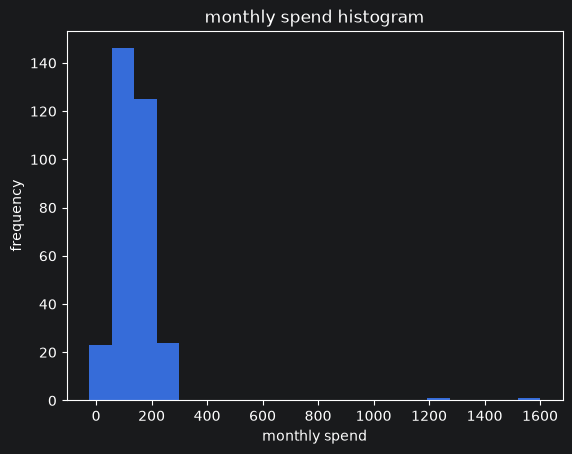

In [24]:
# TODO: Plot the histogram.
figure, axis = plt.subplots()
axis.hist(df["monthly_spend"].dropna(), bins=20)
axis.set_title("monthly spend histogram")
axis.set_xlabel("monthly spend")
axis.set_ylabel("frequency")
plt.show()

### Exercise 23: Support-Calls Boxplot

**Level:** Foundation  
**Learning objective:** Visualize spread and potential outliers.

#### Task
Create a horizontal boxplot.

#### Expected result
```text
One boxplot.
```

<details>
<summary><strong>Hint</strong></summary>

Use `axis.boxplot()`.

</details>

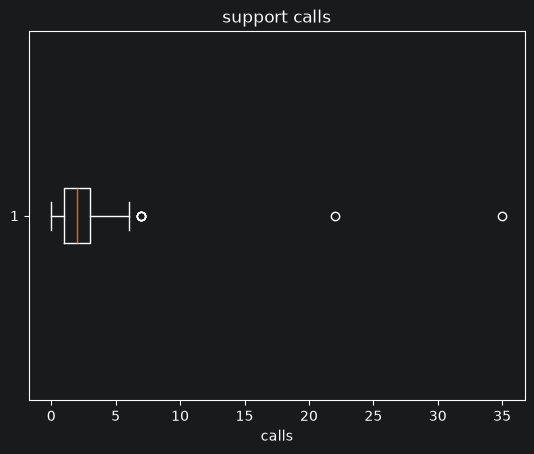

In [25]:
# TODO: Plot the boxplot.
figure, axis = plt.subplots()
axis.boxplot(df["support_calls"].dropna(), orientation="horizontal")
axis.set_title("support calls")
axis.set_xlabel("calls")
plt.show()

### Exercise 24: Contract-Type Frequency

**Level:** Applied  
**Learning objective:** Analyze a categorical variable.

#### Task
Create count and percentage tables and one bar chart.

#### Expected result
```text
Two tables and one chart.
```

<details>
<summary><strong>Hint</strong></summary>

Use `value_counts()`.

</details>

contract_type
Monthly      175
Annual        98
Quarterly     55
Name: count, dtype: int64

 contract_type
Monthly     53.35
Annual      29.88
Quarterly   16.77
Name: proportion, dtype: float64


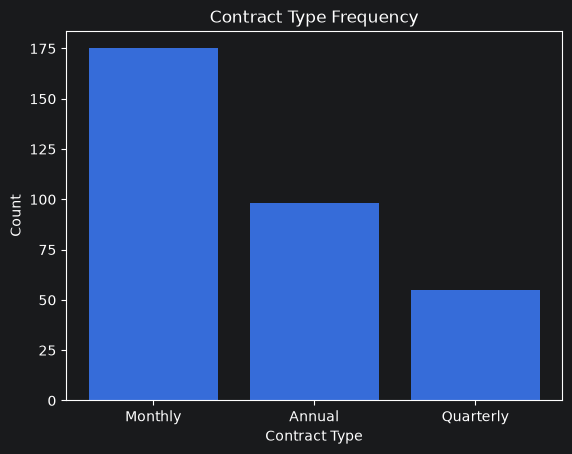

In [26]:
# TODO: Calculate counts and percentages.
# TODO: Plot counts.

# Two tables
contract_counts = df["contract_type"].value_counts()
contract_pct = (df["contract_type"].value_counts(normalize=True) * 100)

print(contract_counts)
print("\n", contract_pct)

# One bar chart
figure, axis = plt.subplots()
axis.bar(contract_counts.index, contract_counts.values)
axis.set_title("Contract Type Frequency")
axis.set_xlabel("Contract Type")
axis.set_ylabel("Count")
plt.show()

### Exercise 25: Reusable Numerical Profile

**Level:** Challenge  
**Learning objective:** Create a profiling function.

#### Task
Return count, missing percentage, mean, median, standard deviation, skewness, minimum, and maximum.

#### Expected result
```text
A pandas Series.
```

<details>
<summary><strong>Hint</strong></summary>

Accept the DataFrame and column name.

</details>

In [27]:
def numerical_profile(
    data: pd.DataFrame,
    column: str,
) -> pd.Series:
    values = data[column]
    return pd.Series({
          "count": values.count(),
          "missing_pct": values.isna().mean() * 100,
          "mean": values.mean(),
          "median": values.median(),
          "std": values.std(),
          "skew": values.skew(),
          "min": values.min(),
          "max": values.max(),
      })

print(numerical_profile(df, "monthly_spend"))

count           320.00
missing_pct       2.44
mean            146.36
median          134.55
std             116.70
skew              8.74
min             -25.00
max           1,600.00
dtype: float64


### Exercise 26: Categorical Cardinality Audit

**Level:** Challenge  
**Learning objective:** Check uniqueness and dominant categories.

#### Task
Build a table containing unique count, missing count, top category, and top-category percentage.

#### Expected result
```text
One row per non-numerical column.
```

<details>
<summary><strong>Hint</strong></summary>

Use `value_counts(dropna=False)`.

</details>

In [28]:
# TODO: Build categorical_audit.
categorical_cols = df.select_dtypes(exclude="number").columns

categorical_audit = pd.DataFrame([
    {
        "column": col,
        "unique": df[col].nunique(),
        "missing": df[col].isna().sum(),
        "top_category": df[col].value_counts(dropna=False).index[0],
        "top_pct": (df[col].value_counts(normalize=True, dropna=False).iloc[0] * 100),
    }
    for col in other_columns
])
categorical_audit

,column,unique,missing,top_category,top_pct
0,customer_id,320,0,CUST-0013,0.61
1,gender,2,9,Male,50.91
2,city,5,10,Riyadh,38.72
3,contract_type,3,0,Monthly,53.35
4,payment_method,4,5,Credit Card,32.01
5,is_premium,2,0,False,71.95
6,signup_date,293,0,2024-04-15 00:00:00,0.91
7,churn,2,0,No,89.63


# 7. Outlier Detection

An outlier may be:

- an entry error,
- an impossible value,
- a valid rare case,
- an influential business event.

## IQR Method

```text
IQR = Q3 - Q1
Lower = Q1 - 1.5 × IQR
Upper = Q3 + 1.5 × IQR
```

## Z-Score

```text
z = (x - mean) / standard deviation
```

The z-score method is sensitive to skewness and extreme observations.

Do not remove an outlier before deciding whether it is invalid, influential, or legitimately rare.

## Treatment Options

- correct from source,
- set impossible values to missing,
- keep and document,
- cap or winsorize,
- log-transform,
- use robust scaling,
- analyze results with and without extremes.

Both methods find **outliers**, but measure "far from normal" differently.

### IQR Method

Based on **quartiles** (median-style). Outlier = outside `Q1 − 1.5×IQR` to `Q3 + 1.5×IQR`.

- **Robust** — extreme values don't distort the cutoffs.
- Best for **skewed** data.

**Example** — `support_calls` (Q1=1, Q3=3, IQR=2): upper bound = 3 + 1.5×2 = **6**, so 35 calls → outlier ✓

### Z-Score Method

Based on **mean & standard deviation**. Z = how many std-devs a value is from the mean. Outlier usually = `|Z| > 3`.

- **Not robust** — outliers inflate the mean/std, hiding themselves.
- Best for **symmetric / bell-shaped** data.

**Example** — mean=2.3, std=1.9, value=35: Z = (35 − 2.3) / 1.9 ≈ **17** → past 3 → outlier ✓

### Quick Comparison

| | IQR | Z-score |
|---|---|---|
| Built on | median / quartiles | mean / std |
| Robust to outliers? | **Yes** | No |
| Best for | skewed data | symmetric data |
| Typical rule | outside 1.5×IQR fences | `\|Z\| > 3` |

**Rule of thumb:** skewed data (like your `monthly_spend`, skew 8.7) → use **IQR**. Clean bell curve → either works.


### Exercise 27: IQR Detection Function

**Level:** Applied  
**Learning objective:** Create reusable outlier detection.

#### Task
Return bounds, outlier count, and outlier rows.

#### Expected result
```text
A dictionary containing the analysis.
```

<details>
<summary><strong>Hint</strong></summary>

Drop missing values before quartile calculation.

</details>

In [29]:
def detect_iqr_outliers(
    data: pd.DataFrame,
    column: str,
) -> dict:
    values = data[column].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    is_outlier = (data[column] < lower_bound) | (data[column] > upper_bound)

    return {
        "column": column,
        "q1": q1,
        "q3": q3,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(is_outlier.sum()),
        "outlier_rows": data.loc[is_outlier],
    }

### Exercise 28: Monthly-Spend Outliers

**Level:** Applied  
**Learning objective:** Apply IQR analysis.

#### Task
Print bounds, count, and sorted outlier values.

#### Expected result
```text
Dataset-dependent output.
```

<details>
<summary><strong>Hint</strong></summary>

Use the function from Exercise 27.

</details>

In [30]:
# TODO: Analyze monthly_spend outliers.
spend_outliers = detect_iqr_outliers(df, "monthly_spend")

print(f"Lower bound: {spend_outliers['lower_bound']:.2f}")
print(f"Upper bound: {spend_outliers['upper_bound']:.2f}")
print("Outlier count:", spend_outliers["outlier_count"])
print("Outlier values:", sorted(spend_outliers["outlier_rows"]["monthly_spend"].tolist()))

Lower bound: -13.09
Upper bound: 289.23
Outlier count: 4
Outlier values: [-25.0, 297.84, 1250.0, 1600.0]


### Exercise 29: Multi-Variable Outlier Summary

**Level:** Challenge  
**Learning objective:** Compare outlier prevalence.

#### Task
Create a summary for age, tenure, spend, calls, satisfaction, and purchases.

#### Expected result
```text
Include lower bound, upper bound, and count.
```

<details>
<summary><strong>Hint</strong></summary>

Loop through selected numerical variables.

</details>

In [31]:
# TODO: Build outlier_summary.
numerical_columns = [
    "age", "tenure_months", "monthly_spend",
    "support_calls", "satisfaction_score", "purchases_last_6m",
]

summary_rows = []
for column in numerical_columns:
    result = detect_iqr_outliers(df, column)
    summary_rows.append({
        "column": column,
        "lower_bound": result["lower_bound"],
        "upper_bound": result["upper_bound"],
        "outlier_count": result["outlier_count"],
        "outlier_pct": result["outlier_count"] / df[column].count() * 100,
    })

outlier_summary = pd.DataFrame(summary_rows).sort_values("outlier_count", ascending=False)
outlier_summary

,column,lower_bound,upper_bound,outlier_count,outlier_pct
3,support_calls,-2.00,6.00,7,2.13
0,age,9.50,61.50,5,1.52
2,monthly_spend,-13.09,289.23,4,1.25
4,satisfaction_score,1.74,5.68,2,0.63
1,tenure_months,-30.00,106.00,1,0.30
5,purchases_last_6m,-2.50,17.50,1,0.30


### Exercise 30: Domain Invalidity

**Level:** Challenge  
**Learning objective:** Separate impossible values from statistical outliers.

#### Task
Count values violating domain rules for age, tenure, spend, satisfaction, support calls, and purchases.

#### Expected result
```text
One count per rule.
```

<details>
<summary><strong>Hint</strong></summary>

Define explicit expected ranges.

</details>

In [32]:
# TODO: Create and evaluate domain rules.
domain_rules = {
    "age": (0, 100),
    "tenure_months": (0, 120),
    "monthly_spend": (0, np.inf),
    "satisfaction_score": (1, 5),
    "support_calls": (0, np.inf),
    "purchases_last_6m": (0, np.inf),
}

invalid_rows = []
for column, (minimum, maximum) in domain_rules.items():
    values = df[column]
    is_invalid = (values < minimum) | (values > maximum)
    invalid_rows.append({
        "column": column,
        "expected_min": minimum,
        "expected_max": maximum,
        "invalid_count": int(is_invalid.sum()),
        "invalid_values": sorted(values[is_invalid].unique().tolist()),
    })

domain_invalidity = pd.DataFrame(invalid_rows)
domain_invalidity

,column,expected_min,expected_max,invalid_count,invalid_values
0,age,0,100.00,2,"[-4.0, 145.0]"
1,tenure_months,0,120.00,1,[160.0]
2,monthly_spend,0,inf,1,[-25.0]
3,satisfaction_score,1,5.00,1,[8.5]
4,support_calls,0,inf,0,[]
5,purchases_last_6m,0,inf,0,[]


### Exercise 31: Outlier Decision Register

**Level:** Challenge  
**Learning objective:** Document treatment choices.

#### Task
Create a table with variable, issue, evidence, decision, and justification.

#### Expected result
```text
At least six rows.
```

<details>
<summary><strong>Hint</strong></summary>

Use both IQR and domain analysis.

</details>

In [33]:
# TODO: Build outlier_decisions.
outlier_decisions = pd.DataFrame([
    {"variable": "age", "issue": "Impossible values",
        "evidence": "-4 and 145 outside 18-100. 5 IQR outliers",
        "decision": "Set to missing", "justification": "Cannot be a real age. safer than guessing"},
    {"variable": "satisfaction_score", "issue": "Out of scale",
        "evidence": "8.5 on a documented 1-5 scale",
        "decision": "Set to missing", "justification": "Scale violation, likely entry error"},
    {"variable": "monthly_spend", "issue": "Negative value",
        "evidence": "-25.00 SAR. spend must be non-negative",
        "decision": "Set to missing", "justification": "Impossible unless refunds are modelled"},
    {"variable": "monthly_spend", "issue": "Extreme but valid",
        "evidence": "1,250 and 1,600 vs upper bound 289",
        "decision": "Keep, flag", "justification": "Plausible high-value customers. drives revenue"},
    {"variable": "tenure_months", "issue": "Implausible duration",
        "evidence": "160 months = 13.3 years",
        "decision": "Investigate", "justification": "Not impossible. verify against signup_date"},
    {"variable": "support_calls", "issue": "Statistical outliers only",
        "evidence": "7 IQR outliers (22, 35). 0 domain violations",
        "decision": "Keep", "justification": "Right-skewed count data. tail is genuine"},
    {"variable": "purchases_last_6m", "issue": "Statistical outlier only",
        "evidence": "95 purchases. above bound 17.5, no rule broken",
        "decision": "Keep, flag", "justification": "Possible bulk buyer. verify before modelling"},
])

outlier_decisions

,variable,issue,evidence,decision,justification
0,age,Impossible values,-4 and 145 outside 18-100. 5 IQR outliers,Set to missing,Cannot be a real age. safer than guessing
1,satisfaction_score,Out of scale,8.5 on a documented 1-5 scale,Set to missing,"Scale violation, likely entry error"
2,monthly_spend,Negative value,-25.00 SAR. spend must be non-negative,Set to missing,Impossible unless refunds are modelled
3,monthly_spend,Extreme but valid,"1,250 and 1,600 vs upper bound 289","Keep, flag",Plausible high-value customers. drives revenue
4,tenure_months,Implausible duration,160 months = 13.3 years,Investigate,Not impossible. verify against signup_date
5,support_calls,Statistical outliers only,"7 IQR outliers (22, 35). 0 domain violations",Keep,Right-skewed count data. tail is genuine
6,purchases_last_6m,Statistical outlier only,"95 purchases. above bound 17.5, no rule broken","Keep, flag",Possible bulk buyer. verify before modelling


# 8. Relationships and Correlations

## Numerical vs Numerical

- correlation,
- scatter plot,
- grouped statistics.

## Categorical vs Numerical

- group means and medians,
- separate boxplots,
- distribution comparison.

## Categorical vs Categorical

- crosstab,
- row percentages.

Correlation does not prove causation and may miss nonlinear relationships.

## Correlation Matrix

```python
correlation = df[numeric_columns].corr()
```

Values close to 1 or -1 indicate stronger linear relationships.

Self-correlation and duplicate variable pairs should be removed when listing strongest relationships.

### Exercise 32: Correlation Matrix

**Level:** Foundation  
**Learning objective:** Measure numerical relationships.

#### Task
Calculate the numerical correlation matrix.

#### Expected result
```text
A square matrix.
```

<details>
<summary><strong>Hint</strong></summary>

Use `.corr()`.

</details>

In [34]:
# TODO: Create correlation_matrix.
correlation_matrix = df[numeric_columns].corr()
correlation_matrix

,age,tenure_months,monthly_spend,support_calls,satisfaction_score,purchases_last_6m
age,1.00,-0.08,-0.00,-0.04,-0.03,0.00
tenure_months,-0.08,1.00,0.18,-0.09,0.09,0.26
monthly_spend,-0.00,0.18,1.00,-0.07,0.00,0.08
support_calls,-0.04,-0.09,-0.07,1.00,-0.27,-0.04
satisfaction_score,-0.03,0.09,0.00,-0.27,1.00,0.09
purchases_last_6m,0.00,0.26,0.08,-0.04,0.09,1.00


### Exercise 33: Strongest Correlation Pairs

**Level:** Applied  
**Learning objective:** Extract useful relationships.

#### Task
List the five strongest absolute correlations excluding duplicate pairs and the diagonal.

#### Expected result
```text
Five variable pairs.
```

<details>
<summary><strong>Hint</strong></summary>

Use the upper triangle of the matrix.

</details>

In [35]:
# TODO: Extract the strongest pairs.
upper_triangle = correlation_matrix.where(
      np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

strongest_pairs = (
    upper_triangle.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
    .assign(abs_correlation=lambda frame: frame["correlation"].abs())
    .sort_values("abs_correlation", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

strongest_pairs

,variable_1,variable_2,correlation,abs_correlation
0,support_calls,satisfaction_score,-0.27,0.27
1,tenure_months,purchases_last_6m,0.26,0.26
2,tenure_months,monthly_spend,0.18,0.18
3,satisfaction_score,purchases_last_6m,0.09,0.09
4,tenure_months,support_calls,-0.09,0.09


### Exercise 34: Correlation Heatmap

**Level:** Applied  
**Learning objective:** Visualize numerical correlations.

#### Task
Create one labeled Matplotlib heatmap with a colorbar.

#### Expected result
```text
One heatmap.
```

<details>
<summary><strong>Hint</strong></summary>

Use `imshow()`.

</details>

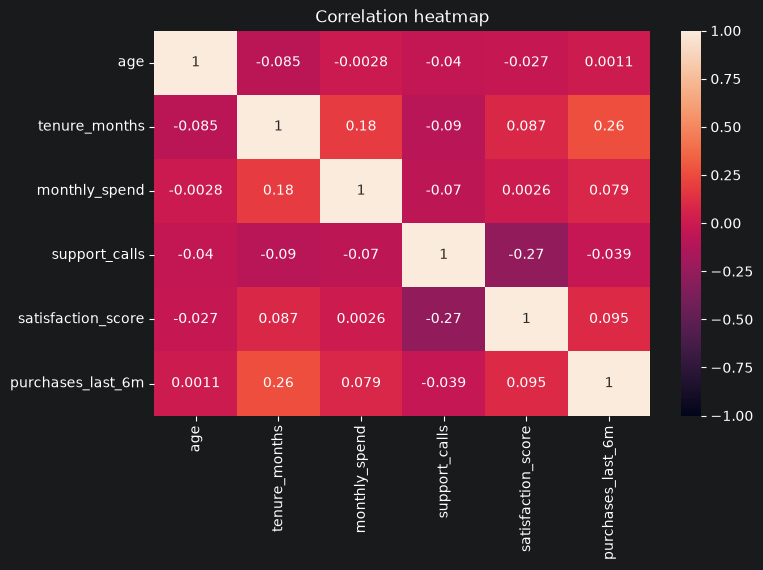

In [36]:
# TODO: Create the heatmap.
plt.figure(figsize=(8, 5))

sns.heatmap(
    data=correlation_matrix,
    annot=True,
    vmin=-1,
    vmax=1
)

plt.title("Correlation heatmap")
plt.show()

### Exercise 35: Tenure and Spend

**Level:** Applied  
**Learning objective:** Analyze a numerical relationship.

#### Task
Calculate correlation and create a scatter plot.

#### Expected result
```text
One correlation value and one scatter plot.
```

<details>
<summary><strong>Hint</strong></summary>

Drop rows missing either variable.

</details>

Correlation between tenure and monthly spend: 0.18


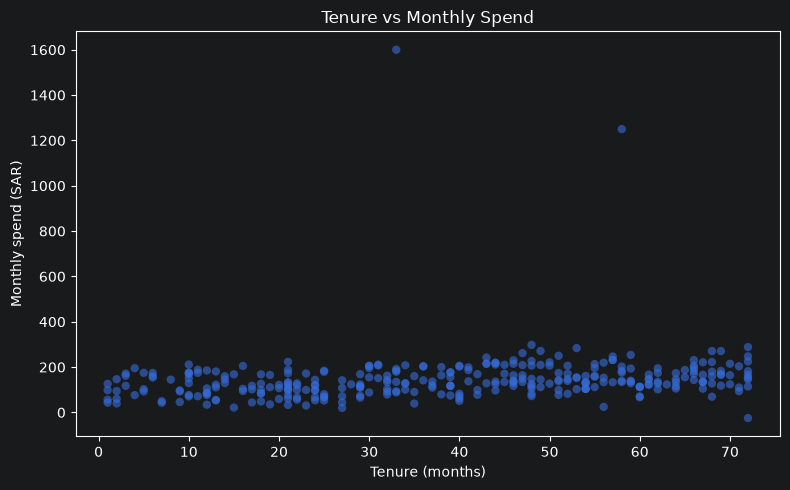

In [37]:
# TODO: Calculate correlation.
pair = df[["tenure_months", "monthly_spend"]].dropna()
tenure_spend_correlation = pair["tenure_months"].corr(pair["monthly_spend"])
print(f"Correlation between tenure and monthly spend: {tenure_spend_correlation:.2f}")

# TODO: Create scatter plot.
figure, axis = plt.subplots(figsize=(8, 5))
axis.scatter(pair["tenure_months"], pair["monthly_spend"], alpha=0.6, edgecolors="none")
axis.set_title("Tenure vs Monthly Spend")
axis.set_xlabel("Tenure (months)")
axis.set_ylabel("Monthly spend (SAR)")
plt.tight_layout()
plt.show()

### Exercise 36: Target Group Medians

**Level:** Applied  
**Learning objective:** Compare numerical variables across churn classes.

#### Task
Compare median tenure, spend, calls, satisfaction, and purchases.

#### Expected result
```text
A grouped median table.
```

<details>
<summary><strong>Hint</strong></summary>

Use `groupby('churn').median(numeric_only=True)`.

</details>

In [38]:
# TODO: Create churn_median_comparison.
churn_median_comparison = df.groupby("churn").median(numeric_only=True)
churn_median_comparison.loc["difference"] = (
    churn_median_comparison.loc["Yes"] - churn_median_comparison.loc["No"]
)

churn_median_comparison

,age,tenure_months,monthly_spend,support_calls,satisfaction_score,is_premium,purchases_last_6m
churn,,,,,,,
No,36.00,39.00,134.55,2.00,3.84,0.00,8.00
Yes,34.00,33.00,139.88,2.00,3.53,0.00,7.00
difference,-2.00,-6.00,5.33,0.00,-0.31,0.00,-1.00


### Exercise 37: Contract Type vs Churn

**Level:** Applied  
**Learning objective:** Study two categorical variables.

#### Task
Create count and row-percentage crosstabs.

#### Expected result
```text
Two tables.
```

<details>
<summary><strong>Hint</strong></summary>

Use `pd.crosstab()`.

</details>

In [39]:
# TODO: Build both crosstabs.
contract_churn_counts = pd.crosstab(df["contract_type"], df["churn"])

contract_churn_pct = pd.crosstab(
    df["contract_type"], df["churn"], normalize="index"
) * 100

print("Counts:")
print(contract_churn_counts)
print("\nRow percentages:")
print(contract_churn_pct.round(2))

Counts:
churn           No  Yes
contract_type          
Annual          93    5
Monthly        149   26
Quarterly       52    3

Row percentages:
churn            No   Yes
contract_type            
Annual        94.90  5.10
Monthly       85.14 14.86
Quarterly     94.55  5.45


### Exercise 38: Premium Membership and Spend

**Level:** Challenge  
**Learning objective:** Compare a Boolean group with a numerical variable.

#### Task
Calculate grouped statistics and create two separate boxplot figures.

#### Expected result
```text
A grouped table and two figures.
```

<details>
<summary><strong>Hint</strong></summary>

Create one figure for each group.

</details>

            count   mean  median    std    min      max
is_premium                                             
False         229 126.29  117.37 130.32 -25.00 1,600.00
True           91 196.85  202.42  40.55  98.06   297.84


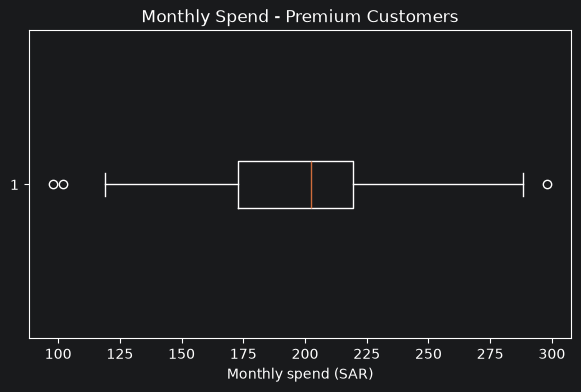

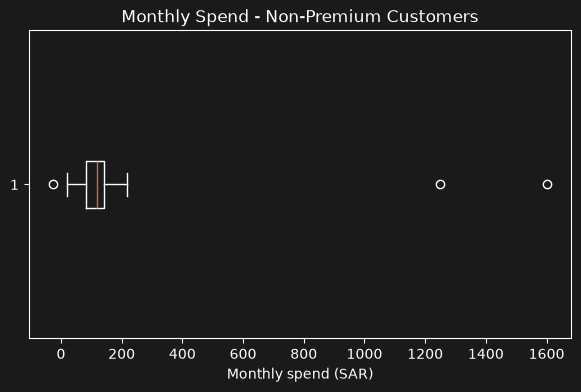

In [40]:
# TODO: Calculate grouped statistics.
premium_spend_stats = df.groupby("is_premium")["monthly_spend"].agg(
      ["count", "mean", "median", "std", "min", "max"]
)
print(premium_spend_stats)

premium_spend = df.loc[df["is_premium"], "monthly_spend"].dropna()
standard_spend = df.loc[~df["is_premium"], "monthly_spend"].dropna()

# TODO: Plot premium customers in one figure.
figure, axis = plt.subplots(figsize=(7, 4))

axis.boxplot(premium_spend, orientation="horizontal")
axis.set_title("Monthly Spend - Premium Customers")
axis.set_xlabel("Monthly spend (SAR)")
plt.show()

# TODO: Plot non-premium customers in another figure.
figure, axis = plt.subplots(figsize=(7, 4))

axis.boxplot(standard_spend, orientation="horizontal")
axis.set_title("Monthly Spend - Non-Premium Customers")
axis.set_xlabel("Monthly spend (SAR)")
plt.show()

### Exercise 39: Relationship Findings Register

**Level:** Challenge  
**Learning objective:** Interpret evidence.

#### Task
Document at least five relationships with question, evidence, interpretation, and caution.

#### Expected result
```text
At least five rows.
```

<details>
<summary><strong>Hint</strong></summary>

Use correlations, group statistics, and crosstabs.

</details>

In [41]:
# TODO: Build relationship_findings.
relationship_findings = pd.DataFrame([
    {"question": "Does contract type affect churn?",
    "evidence": "Monthly 14.86% churn vs Annual 5.10% and Quarterly 5.45%",
    "interpretation": "Monthly customers churn about 3x more. strongest signal found",
    "caution": "Only 5 and 3 churners in Annual/Quarterly. small counts"},

    {"question": "Do support calls relate to satisfaction?",
    "evidence": "Correlation -0.27, the strongest numerical pair",
    "interpretation": "More calls go with lower satisfaction",
    "caution": "Weak, direction unclear. unhappy customers may call more, or calling may cause unhappiness"},

    {"question": "Does tenure relate to purchases?",
    "evidence": "Correlation 0.26",
    "interpretation": "Longer-standing customers buy slightly more",
    "caution": "Weak, tenure explains under 7% of the variation"},

    {"question": "Does tenure relate to monthly spend?",
    "evidence": "Correlation 0.18, rising to 0.35 after removing 1250 and 1600",
    "interpretation": "Weak positive link, hidden by two extreme values",
    "caution": "Two rows out of 320 halve the measured relationship"},

    {"question": "Do premium customers spend more?",
    "evidence": "Median 202.42 vs 117.37 SAR. premium std 40.55 vs 130.32",
    "interpretation": "Premium spend more and far more consistently",
    "caution": "Not causal. heavy spenders likely buy premium in the first place"},

    {"question": "Do churners differ before leaving?",
    "evidence": "Median tenure 33 vs 39 months. satisfaction 3.53 vs 3.84",
    "interpretation": "Churners are newer and slightly less satisfied",
     "caution": "Only 34 churners. all gaps are small"},
])

relationship_findings

,question,evidence,interpretation,caution
0,Does contract type affect churn?,Monthly 14.86% churn vs Annual 5.10% and Quart...,Monthly customers churn about 3x more. stronge...,Only 5 and 3 churners in Annual/Quarterly. sma...
1,Do support calls relate to satisfaction?,"Correlation -0.27, the strongest numerical pair",More calls go with lower satisfaction,"Weak, direction unclear. unhappy customers may..."
2,Does tenure relate to purchases?,Correlation 0.26,Longer-standing customers buy slightly more,"Weak, tenure explains under 7% of the variation"
3,Does tenure relate to monthly spend?,"Correlation 0.18, rising to 0.35 after removin...","Weak positive link, hidden by two extreme values",Two rows out of 320 halve the measured relatio...
4,Do premium customers spend more?,Median 202.42 vs 117.37 SAR. premium std 40.55...,Premium spend more and far more consistently,Not causal. heavy spenders likely buy premium ...
5,Do churners differ before leaving?,Median tenure 33 vs 39 months. satisfaction 3....,Churners are newer and slightly less satisfied,Only 34 churners. all gaps are small


# 9. Class-Balance Analysis

For classification, inspect the target distribution.

```python
counts = df["churn"].value_counts()
percentages = df["churn"].value_counts(normalize=True) * 100
```

An imbalanced target may make accuracy misleading.

Consider:

- stratified train/test split,
- precision,
- recall,
- F1-score,
- confusion matrix,
- ROC-AUC,
- PR-AUC,
- class weights,
- resampling when justified.

### Exercise 40: Target Distribution

**Level:** Foundation  
**Learning objective:** Measure class balance.

#### Task
Print churn counts and percentages.

#### Expected result
```text
Approximate counts: {'No': 294, 'Yes': 34}
```

<details>
<summary><strong>Hint</strong></summary>

Use `value_counts()`.

</details>

In [42]:
# TODO: Calculate and print counts and percentages.
churn_counts = df["churn"].value_counts()
churn_pct = df["churn"].value_counts(normalize=True) * 100

print("churn counts:", churn_counts)
print("\nchurn percentages:", churn_pct.round(2))

churn counts: churn
No     294
Yes     34
Name: count, dtype: int64

churn percentages: churn
No    89.63
Yes   10.37
Name: proportion, dtype: float64


### Exercise 41: Target Bar Chart

**Level:** Foundation  
**Learning objective:** Visualize class balance.

#### Task
Create one labeled bar chart.

#### Expected result
```text
One chart.
```

<details>
<summary><strong>Hint</strong></summary>

Plot the count Series.

</details>

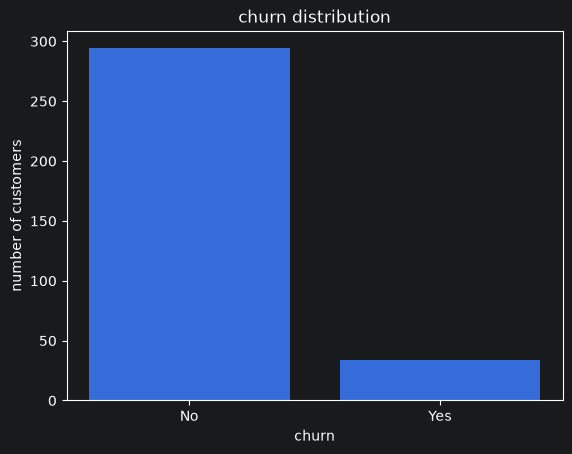

In [43]:
# TODO: Plot churn counts.
figure, axis = plt.subplots()
axis.bar(
    x=churn_counts.index,
    height=churn_counts.values,
)
axis.set_title("churn distribution")
axis.set_xlabel("churn")
axis.set_ylabel("number of customers")
plt.show()

### Exercise 42: Balance by Contract Type

**Level:** Applied  
**Learning objective:** Inspect target balance within subgroups.

#### Task
Calculate churn percentages within each contract type.

#### Expected result
```text
A row-normalized crosstab.
```

<details>
<summary><strong>Hint</strong></summary>

Use `normalize='index'`.

</details>

In [44]:
# TODO: Calculate the crosstab.
churn_by_contract = pd.crosstab(
    df["contract_type"], df["churn"], normalize="index"
) * 100

churn_by_contract

churn,No,Yes
contract_type,,
Annual,94.90,5.10
Monthly,85.14,14.86
Quarterly,94.55,5.45


### Exercise 43: Imbalance Recommendation

**Level:** Challenge  
**Learning objective:** Connect EDA to modeling decisions.

#### Task
Write a recommendation covering split strategy, metrics, and whether resampling should be considered.

#### Expected result
```text
A printed recommendation.
```

<details>
<summary><strong>Hint</strong></summary>

Base the recommendation on observed percentages.

</details>

In [45]:
recommendation = '''
CLASS IMBALANCE RECOMMENDATION

Balance: No 89.63% (294), Yes 10.37% (34). About 8.6 to 1.

SPLIT
Use a stratified split so both sets keep the 10.37% churn rate.

METRICS
No relying on accuracy. predicting "No" for everyone already scores 89.63%.
Use precision, recall, F1, and ROC-AUC, with recall on churn as the main one.

RESAMPLING
Consider it, but start with class_weight="balanced". If recall is still
too low, try SMOTE on the training fold only, never on the test set.
'''

print(recommendation)


CLASS IMBALANCE RECOMMENDATION

Balance: No 89.63% (294), Yes 10.37% (34). About 8.6 to 1.

SPLIT
Use a stratified split so both sets keep the 10.37% churn rate.

METRICS
No relying on accuracy. predicting "No" for everyone already scores 89.63%.
Use precision, recall, F1, and ROC-AUC, with recall on churn as the main one.

RESAMPLING
Consider it, but start with class_weight="balanced". If recall is still
too low, try SMOTE on the training fold only, never on the test set.



# 10. Domain-Validity and Logical Checks

Statistics do not replace domain knowledge.

Check:

- plausible ages,
- non-negative spending,
- score ranges,
- allowed categories,
- identifier format,
- date consistency,
- logical relationships between fields.

### Exercise 44: Allowed Categories

**Level:** Applied  
**Learning objective:** Validate categorical domains.

#### Task
Check gender, contract type, payment method, and churn against allowed sets.

#### Expected result
```text
One invalid count per column.
```

<details>
<summary><strong>Hint</strong></summary>

Use `.isin()` and ignore missing values appropriately.

</details>

In [46]:
# TODO: Define allowed categories.
allowed_categories = {
    "gender": {"Male", "Female"},
    "contract_type": {"Quarterly", "Monthly", "Annual"},
    "payment_method": {"Credit Card", "Bank Transfer", "Cash", "Digital Wallet"},
    "churn": {"Yes", "No"}
}

# TODO: Print invalid counts.
for column, allowed in allowed_categories.items():
    values = df[column].dropna()
    invalid = values[~values.isin(allowed)]
    print(f"{column}: {len(invalid)} invalid, {df[column].isna().sum()} missing")

gender: 0 invalid, 9 missing
contract_type: 0 invalid, 0 missing
payment_method: 0 invalid, 5 missing
churn: 0 invalid, 0 missing


### Exercise 45: Customer-ID Validation

**Level:** Applied  
**Learning objective:** Check completeness, uniqueness, and format.

#### Task
Count null IDs, duplicate IDs, and malformed IDs.

#### Expected result
```text
Three validation counts.
```

<details>
<summary><strong>Hint</strong></summary>

A valid ID starts with `CUST-` and has nine characters.

</details>

In [47]:
# TODO: Validate customer_id.
null_ids = df["customer_id"].isna().sum()
duplicate_ids = df["customer_id"].duplicated().sum()

valid_format = df["customer_id"].str.match(r"^CUST-\d{4}$")
malformed_ids = (~valid_format & df["customer_id"].notna()).sum()

print("null IDs:", null_ids)
print("duplicate IDs:", duplicate_ids)
print("malformed IDs:", malformed_ids)

null IDs: 0
duplicate IDs: 8
malformed IDs: 0


### Exercise 46: Date-Tenure Consistency

**Level:** Challenge  
**Learning objective:** Compare related variables.

#### Task
Estimate account age from signup date relative to 2026-07-01 and flag differences greater than six months.

#### Expected result
```text
A table of suspicious rows.
```

<details>
<summary><strong>Hint</strong></summary>

Use date differences divided by approximately 30.44 days.

</details>

In [48]:
# TODO: Calculate estimated tenure.
reference_date = df["signup_date"].max()
estimated_tenure = (reference_date - df["signup_date"]).dt.days / 30.44

tenure_difference = (df["tenure_months"] - estimated_tenure).abs()

# TODO: Flag inconsistent rows.
inconsistent = tenure_difference > 6

print("Reference date:", reference_date.date())
print("Inconsistent rows (>6 months apart):", inconsistent.sum())
print("Median difference:", round(tenure_difference.median(), 2), "months")

print("\nWorst 5 mismatches:")
print(
    df.assign(estimated=estimated_tenure.round(1), difference=tenure_difference.round(1))
    .loc[inconsistent]
    .nlargest(5, "difference")[["customer_id", "signup_date", "tenure_months", "estimated", "difference"]]
)

Reference date: 2025-09-29
Inconsistent rows (>6 months apart): 263
Median difference: 20.49 months

Worst 5 mismatches:
    customer_id signup_date  tenure_months  estimated  difference
75    CUST-0076  2023-03-10         160.00      30.70      129.30
10    CUST-0011  2025-06-28          70.00       3.10       66.90
224   CUST-0225  2025-05-01          68.00       5.00       63.00
225   CUST-0226  2024-11-21          71.00      10.20       60.80
204   CUST-0205  2025-08-08          62.00       1.70       60.30


### Exercise 47: Data-Quality Scorecard

**Level:** Challenge  
**Learning objective:** Summarize quality dimensions.

#### Task
Create a scorecard for completeness, uniqueness, validity, consistency, and notes.

#### Expected result
```text
One row per dimension.
```

<details>
<summary><strong>Hint</strong></summary>

Use percentages where possible.

</details>

In [49]:
# TODO: Build data_quality_scorecard.
completeness_score = df.notna().mean().mean() * 100
uniqueness_score = df["customer_id"].nunique() / len(df) * 100

invalid_count = sum(
    int(((df[column] < minimum) | (df[column] > maximum)).sum())
    for column, (minimum, maximum) in domain_rules.items()
)
checked_count = sum(int(df[column].notna().sum()) for column in domain_rules)
validity_score = (1 - invalid_count / checked_count) * 100
consistency_score = (tenure_difference <= 6).mean() * 100

data_quality_scorecard = pd.DataFrame([
    {"dimension": "Completeness", "score_pct": round(completeness_score, 2),
    "note": "44 missing cells out of 4592. satisfaction_score worst at 3.66%"},
    {"dimension": "Uniqueness", "score_pct": round(uniqueness_score, 2),
    "note": "320 unique IDs in 328 rows. 8 fully duplicated records"},
    {"dimension": "Validity", "score_pct": round(validity_score, 2),
    "note": "5 domain violations: age -4 and 145, tenure 160, spend -25, satisfaction 8.5"},
    {"dimension": "Consistency", "score_pct": round(consistency_score, 2),
    "note": "Only 20% of rows agree with signup_date within 6 months"},
])
data_quality_scorecard

,dimension,score_pct,note
0,Completeness,99.04,44 missing cells out of 4592. satisfaction_sco...
1,Uniqueness,97.56,320 unique IDs in 328 rows. 8 fully duplicated...
2,Validity,99.74,"5 domain violations: age -4 and 145, tenure 16..."
3,Consistency,19.82,Only 20% of rows agree with signup_date within...


# 11. Transformations Before Modeling

EDA should identify required preprocessing.

## Missing Values

- median,
- mode,
- explicit `Unknown`,
- missing indicator.

## Categorical Features

- one-hot encoding,
- ordinal encoding only when order is real,
- rare-category consolidation.

## Numerical Features

- standardization,
- robust scaling,
- log transformation,
- clipping after investigation.

## Dates

- year,
- month,
- weekday,
- account age.

## Leakage Warning

Transformations and imputations should be fitted on training data only.

### Exercise 48: Create a Modeling Copy

**Level:** Foundation  
**Learning objective:** Preserve raw data.

#### Task
Create `model_df` from the deduplicated copy.

#### Expected result
```text
The raw DataFrame remains unchanged.
```

<details>
<summary><strong>Hint</strong></summary>

Use `.copy()`.

</details>

In [50]:
# TODO: Create model_df.
model_df = df_deduplicated.copy()

print("raw df:", df.shape)
print("model df:", model_df.shape)

raw df: (328, 14)
model df: (320, 14)


### Exercise 49: Convert Invalid Values to Missing

**Level:** Applied  
**Learning objective:** Prepare invalid observations for treatment.

#### Task
Set domain-invalid age, tenure, spend, satisfaction, calls, and purchases to NaN.

#### Expected result
```text
Invalid values become missing.
```

<details>
<summary><strong>Hint</strong></summary>

Use Boolean masks with `.loc`.

</details>

In [51]:
# TODO: Replace invalid values with np.nan.
missing_before = model_df.isna().sum()

for column, (minimum, maximum) in domain_rules.items():
    is_invalid = (model_df[column] < minimum) | (model_df[column] > maximum)
    print(f"{column}: {int(is_invalid.sum())} invalid ->", sorted(model_df.loc[is_invalid, column].unique().tolist()))
    model_df.loc[is_invalid, column] = np.nan

missing_after = model_df.isna().sum()

print("\nMissing before -> after:")
print(pd.DataFrame({"before": missing_before, "after": missing_after}).loc[list(domain_rules)])

age: 2 invalid -> [-4.0, 145.0]
tenure_months: 1 invalid -> [160.0]
monthly_spend: 1 invalid -> [-25.0]
satisfaction_score: 1 invalid -> [8.5]
support_calls: 0 invalid -> []
purchases_last_6m: 0 invalid -> []

Missing before -> after:
                    before  after
age                      0      2
tenure_months            0      1
monthly_spend            7      8
satisfaction_score      12     13
support_calls            0      0
purchases_last_6m        0      0


### Exercise 50: Impute Selected Variables

**Level:** Applied  
**Learning objective:** Apply simple justified imputations.

#### Task
Use median for numerical variables and mode or `Unknown` for categorical variables.

#### Expected result
```text
Selected columns should have no missing values.
```

<details>
<summary><strong>Hint</strong></summary>

Document each rule in code comments.

</details>

In [52]:
# TODO: Impute numerical variables.
# Median, not mean: monthly_spend is right-skewed and the median resists outliers.
numerical_to_impute = ["age", "tenure_months", "monthly_spend", "satisfaction_score"]

for column in numerical_to_impute:
    median_value = model_df[column].median()
    print(f"{column}: filled with median {median_value:.2f}")
    model_df[column] = model_df[column].fillna(median_value)

# TODO: Impute categorical variables.
# Mode where one category clearly dominates.
for column in ["gender", "payment_method"]:
    mode_value = model_df[column].mode()[0]
    print(f"{column}: filled with mode '{mode_value}'")
    model_df[column] = model_df[column].fillna(mode_value)

# "Unknown" for city: no dominant category, and missing location may be meaningful.
model_df["city"] = model_df["city"].fillna("Unknown")

# TODO: Print remaining missing counts.
print("\nRemaining missing values:")
print(model_df.isna().sum())

age: filled with median 35.00
tenure_months: filled with median 39.00
monthly_spend: filled with median 134.59
satisfaction_score: filled with median 3.79
gender: filled with mode 'Male'
payment_method: filled with mode 'Credit Card'

Remaining missing values:
customer_id           0
age                   0
gender                0
city                  0
tenure_months         0
monthly_spend         0
support_calls         0
satisfaction_score    0
contract_type         0
payment_method        0
is_premium            0
purchases_last_6m     0
signup_date           0
churn                 0
dtype: int64


### Exercise 51: Engineer Date Features

**Level:** Applied  
**Learning objective:** Extract modeling features from dates.

#### Task
Create signup year, signup month, and account age in months.

#### Expected result
```text
Three new columns.
```

<details>
<summary><strong>Hint</strong></summary>

Use the reference date 2026-07-01.

</details>

In [53]:
# TODO: Create date features.
reference_date = pd.Timestamp("2026-07-01")

model_df["signup_year"] = model_df["signup_date"].dt.year
model_df["signup_month"] = model_df["signup_date"].dt.month
model_df["account_age_months"] = (
    (reference_date - model_df["signup_date"]).dt.days / 30.44
).round(1)

print(model_df[["signup_date", "signup_year", "signup_month", "account_age_months"]].head())

  signup_date  signup_year  signup_month  account_age_months
0  2023-09-20         2023             9               33.30
1  2020-04-19         2020             4               74.40
2  2024-02-08         2024             2               28.70
3  2024-04-08         2024             4               26.70
4  2021-04-20         2021             4               62.40


### Exercise 52: Encode the Target

**Level:** Foundation  
**Learning objective:** Convert a binary label to numbers.

#### Task
Create `churn_flag` where No=0 and Yes=1.

#### Expected result
```text
Only 0 and 1.
```

<details>
<summary><strong>Hint</strong></summary>

Use `.map()`.

</details>

In [54]:
# TODO: Create churn_flag.
model_df["churn_flag"] = model_df["churn"].map({"No": 0, "Yes": 1})

# TODO: Print value counts.
print(model_df["churn_flag"].value_counts())
print("\nMissing:", model_df["churn_flag"].isna().sum())

churn_flag
0    287
1     33
Name: count, dtype: int64

Missing: 0


### Exercise 53: One-Hot Encoding

**Level:** Applied  
**Learning objective:** Prepare nominal categorical variables.

#### Task
Create dummy columns for contract type and payment method.

#### Expected result
```text
A new encoded DataFrame.
```

<details>
<summary><strong>Hint</strong></summary>

Use `pd.get_dummies()`.

</details>

In [55]:
# TODO: Create encoded_df.
encoded_df = pd.get_dummies(
    model_df,
    columns=["contract_type", "payment_method"],
    drop_first=True,   # avoid the dummy variable trap
    dtype=int,
)
print("Before:", model_df.shape, "-> After:", encoded_df.shape)

new_columns = [c for c in encoded_df.columns
    if c.startswith(("contract_type_", "payment_method_"))]

print("\nNew columns:", new_columns)
print(encoded_df[new_columns].head())

Before: (320, 18) -> After: (320, 21)

New columns: ['contract_type_Monthly', 'contract_type_Quarterly', 'payment_method_Cash', 'payment_method_Credit Card', 'payment_method_Digital Wallet']
   contract_type_Monthly  contract_type_Quarterly  payment_method_Cash  \
0                      1                        0                    0   
1                      0                        0                    1   
2                      0                        0                    0   
3                      1                        0                    0   
4                      1                        0                    0   

   payment_method_Credit Card  payment_method_Digital Wallet  
0                           0                              1  
1                           0                              0  
2                           0                              0  
3                           1                              0  
4                           1                    

### Exercise 54: Log Transformation

**Level:** Challenge  
**Learning objective:** Reduce strong right skew.

#### Task
Create `monthly_spend_log` and compare skewness before and after.

#### Expected result
```text
Two skewness values.
```

<details>
<summary><strong>Hint</strong></summary>

Use `np.log1p()` after invalid values and missingness are handled.

</details>

In [56]:
# TODO: Transform monthly_spend.
model_df["monthly_spend_log"] = np.log1p(model_df["monthly_spend"])

# TODO: Compare skewness.
skew_before = model_df["monthly_spend"].skew()
skew_after = model_df["monthly_spend_log"].skew()

print(f"Skewness before: {skew_before:.2f}")
print(f"Skewness after:  {skew_after:.2f}")

Skewness before: 8.88
Skewness after:  -0.20


### Exercise 55: Transformation Plan

**Level:** Challenge  
**Learning objective:** Document preprocessing decisions.

#### Task
Create a plan with variable, issue, transformation, reason, and leakage precaution.

#### Expected result
```text
At least eight rows.
```

<details>
<summary><strong>Hint</strong></summary>

Include date, categorical, numerical, target, and ID variables.

</details>

In [57]:
# TODO: Build transformation_plan.
transformation_plan = pd.DataFrame([
    {"variable": "customer_id", "issue": "Identifier, 8 duplicated IDs",
       "transformation": "Drop before modelling. used only for deduplication",
       "reason": "No predictive value. risks memorising individual customers",
       "leakage_precaution": "Deduplicate before splitting so copies cannot span train and test"},

    {"variable": "signup_date", "issue": "Datetime, unusable as a raw feature",
       "transformation": "Extract signup_year, signup_month, account_age_months",
       "reason": "Models need numbers. date parts capture cohort and seasonality",
       "leakage_precaution": "Fixed reference date 2026-07-01, never Timestamp.today()"},

    {"variable": "tenure_months", "issue": "160 invalid. disagrees with signup_date in 80% of rows",
       "transformation": "Set invalid to NaN, impute median, or drop in favour of account_age_months",
       "reason": "Two columns claim the same fact and contradict each other",
       "leakage_precaution": "Fit the median on the training fold only"},

    {"variable": "age", "issue": "-4 and 145 impossible",
       "transformation": "Set invalid to NaN, then impute median",
       "reason": "Outside any plausible range. skew drops from 2.39 to 0.40 once removed",
       "leakage_precaution": "Fit the median on the training fold only"},

    {"variable": "monthly_spend", "issue": "-25 invalid, skew 8.88. extreme values 1250 and 1600",
       "transformation": "Set -25 to NaN, impute median, add monthly_spend_log via np.log1p",
       "reason": "Log reduces skew to -0.20. extremes kept as legitimate high spenders",
       "leakage_precaution": "Impute before transforming. fit the median on train only"},

    {"variable": "satisfaction_score", "issue": "8.5 out of the 1-5 scale. 13 missing",
       "transformation": "Set invalid to NaN, impute median, add satisfaction_missing indicator",
       "reason": "Missingness itself is informative: 5.88% for churners vs 3.40% for stayers",
       "leakage_precaution": "Create the indicator before imputing, or the signal is erased"},

    {"variable": "city", "issue": "10 missing, no dominant category",
       "transformation": "Fill with 'Unknown', then one-hot encode",
       "reason": "Riyadh is only 38%. forcing the mode would invent a location",
       "leakage_precaution": "Fix the category list on train so test cannot add new columns"},

    {"variable": "gender, payment_method", "issue": "9 and 5 missing",
       "transformation": "Fill with mode, then one-hot encode with drop_first=True",
       "reason": "One category clearly dominates. drop_first avoids the dummy variable trap",
       "leakage_precaution": "Impute before encoding, or missing rows read as the baseline category"},

    {"variable": "contract_type", "issue": "Nominal text, no natural order",
       "transformation": "One-hot encode with drop_first=True",
       "reason": "Integer coding would invent an order. strongest churn signal found (14.86% vs 5%)",
       "leakage_precaution": "Fit the encoder on train and apply to test"},

    {"variable": "churn", "issue": "Text target, imbalanced 89.63/10.37",
       "transformation": "Map to churn_flag (No=0, Yes=1)",
       "reason": "Models need a numeric target. Yes=1 makes churn the positive class",
       "leakage_precaution": "Stratify the split. apply resampling to training folds only"},
])

transformation_plan

,variable,issue,transformation,reason,leakage_precaution
0,customer_id,"Identifier, 8 duplicated IDs",Drop before modelling. used only for deduplica...,No predictive value. risks memorising individu...,Deduplicate before splitting so copies cannot ...
1,signup_date,"Datetime, unusable as a raw feature","Extract signup_year, signup_month, account_age...",Models need numbers. date parts capture cohort...,"Fixed reference date 2026-07-01, never Timesta..."
2,tenure_months,160 invalid. disagrees with signup_date in 80%...,"Set invalid to NaN, impute median, or drop in ...",Two columns claim the same fact and contradict...,Fit the median on the training fold only
3,age,-4 and 145 impossible,"Set invalid to NaN, then impute median",Outside any plausible range. skew drops from 2...,Fit the median on the training fold only
4,monthly_spend,"-25 invalid, skew 8.88. extreme values 1250 an...","Set -25 to NaN, impute median, add monthly_spe...",Log reduces skew to -0.20. extremes kept as le...,Impute before transforming. fit the median on ...
5,satisfaction_score,8.5 out of the 1-5 scale. 13 missing,"Set invalid to NaN, impute median, add satisfa...",Missingness itself is informative: 5.88% for c...,"Create the indicator before imputing, or the s..."
6,city,"10 missing, no dominant category","Fill with 'Unknown', then one-hot encode",Riyadh is only 38%. forcing the mode would inv...,Fix the category list on train so test cannot ...
7,"gender, payment_method",9 and 5 missing,"Fill with mode, then one-hot encode with drop_...",One category clearly dominates. drop_first avo...,"Impute before encoding, or missing rows read a..."
8,contract_type,"Nominal text, no natural order",One-hot encode with drop_first=True,Integer coding would invent an order. stronges...,Fit the encoder on train and apply to test
9,churn,"Text target, imbalanced 89.63/10.37","Map to churn_flag (No=0, Yes=1)",Models need a numeric target. Yes=1 makes chur...,Stratify the split. apply resampling to traini...


# 12. Documenting EDA Findings

A useful finding separates:

1. observation,
2. evidence,
3. interpretation,
4. impact,
5. recommended action.

## Finding Template

| Field | Meaning |
|---|---|
| area | Missingness, outlier, relationship, balance |
| finding | What was observed |
| evidence | Number, percentage, statistic, or chart |
| impact | Why it matters |
| recommended_action | Next step |
| priority | High, medium, low |

A final report should explicitly answer whether the data is ready for analysis and modeling.

### Exercise 56: Findings Register

**Level:** Challenge  
**Learning objective:** Create an auditable EDA record.

#### Task
Document at least twelve findings covering all major EDA areas.

#### Expected result
```text
At least twelve rows.
```

<details>
<summary><strong>Hint</strong></summary>

Use evidence from earlier sections.

</details>

In [58]:
# TODO: Build findings_register.
findings_register = pd.DataFrame([
    {"area": "Consistency", "finding": "tenure_months disagrees with signup_date",
     "evidence": "263 of 328 rows differ by more than 6 months, median gap 20.5",
     "impact": "Tenure drives the churn findings, so if it is wrong those findings are wrong",
     "recommended_action": "Confirm which column is authoritative, or derive tenure from signup_date",
     "priority": "High"},

    {"area": "Relationship", "finding": "Contract type is the strongest churn signal",
     "evidence": "Monthly 14.86% churn vs Annual 5.10% and Quarterly 5.45%",
     "impact": "Only strong predictor found, the rest are weak",
     "recommended_action": "Include contract_type in the model, consider stratifying on it",
     "priority": "High"},

    {"area": "Balance", "finding": "Target is imbalanced",
     "evidence": "No 89.63% (294) vs Yes 10.37% (34), about 8.6 to 1",
     "impact": "Predicting No for everyone already scores 89.63% accuracy",
     "recommended_action": "Stratified split, recall and F1 instead of accuracy, class_weight='balanced'",
     "priority": "High"},

    {"area": "Duplicates", "finding": "Eight fully duplicated records",
     "evidence": "320 unique customer_id values across 328 rows",
     "impact": "Same customer can land in both train and test, inflating scores",
     "recommended_action": "Deduplicate before splitting, done in df_deduplicated",
     "priority": "High"},

    {"area": "Validity", "finding": "Five impossible values across four columns",
     "evidence": "age -4 and 145, tenure 160, spend -25, satisfaction 8.5",
     "impact": "Distorts means and inflates skew, age skew falls from 2.39 to 0.40 once removed",
     "recommended_action": "Set to NaN and impute median",
     "priority": "High"},

    {"area": "Missingness", "finding": "Satisfaction is missing more often for churners",
     "evidence": "5.88% missing for churners vs 3.40% for stayers",
     "impact": "Missingness carries signal, median imputation erases it",
     "recommended_action": "Add a satisfaction_missing indicator before imputing",
     "priority": "Medium"},

    {"area": "Missingness", "finding": "Missing values are few and concentrated",
     "evidence": "44 missing cells of 4592 (99.04% complete), satisfaction worst at 3.66%",
     "impact": "Simple imputation is defensible, no column needs dropping",
     "recommended_action": "Median for numerical, mode or 'Unknown' for categorical",
     "priority": "Low"},

    {"area": "Distribution", "finding": "monthly_spend is severely right-skewed",
     "evidence": "Skew 8.88, mean 146.36 vs median 134.55",
     "impact": "Breaks mean-based methods and distance-based models",
     "recommended_action": "Use median statistics, add monthly_spend_log via np.log1p (skew -0.20)",
     "priority": "Medium"},

    {"area": "Outlier", "finding": "Two extreme spend values are plausible, not invalid",
     "evidence": "1250 and 1600 vs IQR upper bound 289, no domain rule broken",
     "impact": "Halves the tenure-spend correlation, 0.35 down to 0.18",
     "recommended_action": "Keep and flag as high-value customers, do not delete",
     "priority": "Medium"},

    {"area": "Outlier", "finding": "Support calls and purchases have long right tails",
     "evidence": "7 and 1 IQR outliers, maxima 35 calls and 95 purchases, no domain violations",
     "impact": "Genuine tail of count data, not errors",
     "recommended_action": "Keep, verify the 95-purchase customer before modelling",
     "priority": "Low"},

    {"area": "Relationship", "finding": "All numerical correlations are weak",
     "evidence": "Strongest pair is support_calls and satisfaction at -0.27",
     "impact": "No numerical variable predicts churn on its own",
     "recommended_action": "Rely on categorical drivers, do not oversell weak correlations",
     "priority": "Medium"},

    {"area": "Relationship", "finding": "Premium members spend more but churn the same",
     "evidence": "Median spend 202.42 vs 117.37, churn 9.78% vs 10.59%",
     "impact": "Premium predicts spend, not retention",
     "recommended_action": "Use is_premium as a spend feature, do not assume it reduces churn",
     "priority": "Low"},

    {"area": "Validity", "finding": "Categories and ID format are clean",
     "evidence": "0 invalid values across gender, contract_type, payment_method, churn, all IDs match CUST-####",
     "impact": "No standardisation or parsing work needed",
     "recommended_action": "None, keep the check in the pipeline as a regression test",
     "priority": "Low"},
])

findings_register

,area,finding,evidence,impact,recommended_action,priority
0,Consistency,tenure_months disagrees with signup_date,"263 of 328 rows differ by more than 6 months, ...","Tenure drives the churn findings, so if it is ...","Confirm which column is authoritative, or deri...",High
1,Relationship,Contract type is the strongest churn signal,Monthly 14.86% churn vs Annual 5.10% and Quart...,"Only strong predictor found, the rest are weak","Include contract_type in the model, consider s...",High
2,Balance,Target is imbalanced,"No 89.63% (294) vs Yes 10.37% (34), about 8.6 ...",Predicting No for everyone already scores 89.6...,"Stratified split, recall and F1 instead of acc...",High
3,Duplicates,Eight fully duplicated records,320 unique customer_id values across 328 rows,"Same customer can land in both train and test,...","Deduplicate before splitting, done in df_dedup...",High
4,Validity,Five impossible values across four columns,"age -4 and 145, tenure 160, spend -25, satisfa...","Distorts means and inflates skew, age skew fal...",Set to NaN and impute median,High
5,Missingness,Satisfaction is missing more often for churners,5.88% missing for churners vs 3.40% for stayers,"Missingness carries signal, median imputation ...",Add a satisfaction_missing indicator before im...,Medium
6,Missingness,Missing values are few and concentrated,"44 missing cells of 4592 (99.04% complete), sa...","Simple imputation is defensible, no column nee...","Median for numerical, mode or 'Unknown' for ca...",Low
7,Distribution,monthly_spend is severely right-skewed,"Skew 8.88, mean 146.36 vs median 134.55",Breaks mean-based methods and distance-based m...,"Use median statistics, add monthly_spend_log v...",Medium
8,Outlier,"Two extreme spend values are plausible, not in...","1250 and 1600 vs IQR upper bound 289, no domai...","Halves the tenure-spend correlation, 0.35 down...","Keep and flag as high-value customers, do not ...",Medium
9,Outlier,Support calls and purchases have long right tails,"7 and 1 IQR outliers, maxima 35 calls and 95 p...","Genuine tail of count data, not errors","Keep, verify the 95-purchase customer before m...",Low


### Exercise 57: Executive EDA Summary

**Level:** Challenge  
**Learning objective:** Communicate technical findings clearly.

#### Task
Write 250–400 words covering readiness, issues, relationships, balance, and required transformations.

#### Expected result
```text
A structured executive summary.
```

<details>
<summary><strong>Hint</strong></summary>

Use evidence, not general statements.

</details>

In [59]:
eda_executive_summary = '''
READINESS
The data is not ready for modelling yet, but it is close. Most of the problems are small and easy to fix. One problem is not.

THE MAIN ISSUE
tenure_months and signup_date do not agree. I estimated tenure from the signup date and 263 of the 328 rows were off by more than 6 months. The median gap was 20.5 months. One of these two columns is wrong and I cannot tell which one from the data alone. This matters because tenure is the variable my churn findings lean on. I need someone to confirm which column is correct before I trust anything built on it.

OTHER QUALITY ISSUES
The rest is minor. The data is 99.04% complete with only 44 missing cells out of 4592. There are 8 fully duplicated records, which I found by checking customer_id and getting 320 unique values across 328 rows. I found 5 impossible values: age of -4 and 145, tenure of 160, spend of -25, and a satisfaction score of 8.5 on a 1 to 5 scale. All categories and ID formats were clean.

RELATIONSHIPS
Contract type is the only strong signal I found. Monthly customers churn at 14.86% while Annual and Quarterly sit near 5%. That is roughly 3 times higher. The numerical correlations are all weak. The strongest is support calls against satisfaction at -0.27, which is too small to build on. Premium members spend more, 202.42 against 117.37 at the median, but they churn at the same rate as everyone else.

CLASS BALANCE
Churn is imbalanced at 89.63% No and 10.37% Yes, or about 8.6 to 1. Only 34 customers actually churned. I cannot use accuracy as a metric because predicting No for every customer already scores 89.63%.

REQUIRED TRANSFORMATIONS
Set the 5 invalid values to missing and impute with the median. Fill city with Unknown and use the mode for gender and payment method. One-hot encode contract type and payment method. Map churn to 0 and 1. Add a log version of monthly_spend, which brings the skew down from 8.88 to -0.20. Every median and mode has to be fitted on the training data only.
'''

print(eda_executive_summary)


READINESS
The data is not ready for modelling yet, but it is close. Most of the problems are small and easy to fix. One problem is not.

THE MAIN ISSUE
tenure_months and signup_date do not agree. I estimated tenure from the signup date and 263 of the 328 rows were off by more than 6 months. The median gap was 20.5 months. One of these two columns is wrong and I cannot tell which one from the data alone. This matters because tenure is the variable my churn findings lean on. I need someone to confirm which column is correct before I trust anything built on it.

OTHER QUALITY ISSUES
The rest is minor. The data is 99.04% complete with only 44 missing cells out of 4592. There are 8 fully duplicated records, which I found by checking customer_id and getting 320 unique values across 328 rows. I found 5 impossible values: age of -4 and 145, tenure of 160, spend of -25, and a satisfaction score of 8.5 on a 1 to 5 scale. All categories and ID formats were clean.

RELATIONSHIPS
Contract type is 

# 13. Final Guided EDA Project

Complete a full analysis on a fresh copy of the dataset.

## Required Deliverables

### Data Understanding
- purpose,
- unit of analysis,
- target,
- data dictionary.

### Initial Inspection
- samples,
- shape,
- columns,
- data types.

### Quality
- missing values,
- duplicates,
- identifier uniqueness,
- invalid categories,
- unreasonable numerical values.

### Descriptive Analysis
- numerical and categorical summaries,
- distributions,
- class balance.

### Outliers
- IQR results,
- domain-invalid values,
- decisions.

### Relationships
- correlation matrix,
- at least three numerical relationships,
- at least three grouped or categorical comparisons.

### Modeling Preparation
- missing-value strategy,
- encoding,
- scaling/transformation,
- feature engineering,
- leakage risks.

### Final Reporting
- findings register,
- executive summary,
- readiness decision.

In [60]:
# FINAL PROJECT WORKSPACE

# 1. Load a fresh copy.
# 2. Inspect structure and types.
# 3. Analyze missingness and duplicates.
# 4. Validate numerical and categorical values.
# 5. Analyze distributions.
# 6. Detect and interpret outliers.
# 7. Analyze relationships.
# 8. Inspect target balance.
# 9. Create a transformation plan.
# 10. Write findings and final recommendation.

## Final Readiness Decision Template

```text
Dataset readiness: Ready / Conditionally ready / Not ready

Critical issues:

Required cleaning:

Important variables:

Strongest relationships:

Class-balance conclusion:

Required transformations:

Potential leakage risks:

Final recommendation:
```

In [61]:
final_readiness_decision = '''
Dataset readiness:

Critical issues:

Required cleaning:

Important variables:

Strongest relationships:

Class-balance conclusion:

Required transformations:

Potential leakage risks:

Final recommendation:
'''

print(final_readiness_decision)


Dataset readiness:

Critical issues:

Required cleaning:

Important variables:

Strongest relationships:

Class-balance conclusion:

Required transformations:

Potential leakage risks:

Final recommendation:



# Assessment Rubric — 100 Points

| Area | Points |
|---|---:|
| Loading and inspection | 8 |
| Missing values | 10 |
| Duplicates and identifiers | 8 |
| Descriptive statistics | 10 |
| Distribution analysis | 10 |
| Outliers and validity | 12 |
| Relationships and correlations | 14 |
| Target balance | 8 |
| Transformation plan | 10 |
| Documentation | 10 |
| **Total** | **100** |

# Submission Checklist

- [ ] Dataset loaded successfully.
- [ ] Samples displayed.
- [ ] Shape, columns, and types documented.
- [ ] Dates converted.
- [ ] Missing values quantified and interpreted.
- [ ] Duplicate rows and IDs checked.
- [ ] Descriptive statistics reviewed.
- [ ] Numerical and categorical distributions analyzed.
- [ ] Statistical outliers detected.
- [ ] Domain-invalid values identified.
- [ ] Correlations and group relationships studied.
- [ ] Target balance documented.
- [ ] Transformation plan completed.
- [ ] At least twelve findings documented.
- [ ] Executive summary completed.
- [ ] Final readiness decision completed.